<a href="https://colab.research.google.com/github/ShushumnaVazeer/MDS_LAB/blob/main/MDS_Week(6%2C7%2C8).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import scipy.stats as stats

# Load the dataset
df = pd.read_csv("/content/House_Price_Prediction.csv")

# Select independent and dependent variables
X = df[["Area_sqft"]]
y = df["Price_Lakhs"]

# Create and train the linear regression model
model = LinearRegression()
model.fit(X, y)

# Calculate intercept and coefficient
b0 = model.intercept_
b1 = model.coef_[0]

# Predict values
y_pred = model.predict(X)

# Calculate R-squared
r2 = r2_score(y, y_pred)

# Display results
print("Intercept (b0):", b0)
print("Coefficient (b1):", b1)
print("R²:", r2)

# Display regression equation
print("Regression Equation:")
print("Price =", b0, "+", b1, "* Area")

Intercept (b0): 27.778953142082173
Coefficient (b1): 0.08247674702854477
R²: 0.9081879014583163
Regression Equation:
Price = 27.778953142082173 + 0.08247674702854477 * Area


In [3]:
# Calculate residuals
df["Predicted_Price"] = y_pred
df["Residual"] = df["Price_Lakhs"] - df["Predicted_Price"]

# Display residuals
print(df[[
    "Area_sqft",
    "Price_Lakhs",
    "Predicted_Price",
    "Residual"
]].head(20))

    Area_sqft  Price_Lakhs  Predicted_Price   Residual
0        1360       109.43       139.947329 -30.517329
1        1794       199.55       175.742237  23.807763
2        1630       125.13       162.216051 -37.086051
3        1595       189.03       159.329365  29.700635
4        2138       212.60       204.114238   8.485762
5        2669       224.38       247.909391 -23.529391
6         966        59.11       107.451491 -48.341491
7        1738       190.57       171.123539  19.446461
8         830       118.06        96.234653  21.825347
9        1982       166.12       191.247866 -25.127866
10       2635       219.44       245.105182 -25.665182
11       3419       314.57       309.766951   4.803049
12        630        78.74        79.739304  -0.999304
13       2185       241.40       207.990645  33.409355
14       1269       122.98       132.441945  -9.461945
15       2891       288.25       266.219229  22.030771
16       2015       216.20       193.969598  22.230402
17       3

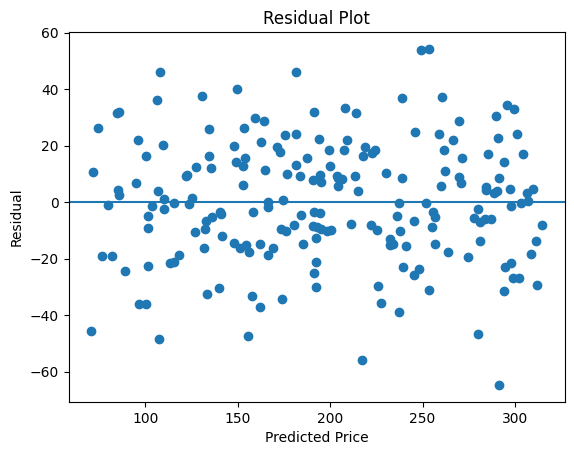

In [4]:
# Plot residuals
plt.scatter(df["Predicted_Price"], df["Residual"])

# Add zero reference line
plt.axhline(0)

# Add labels and title
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot")

# Display plot
plt.show()

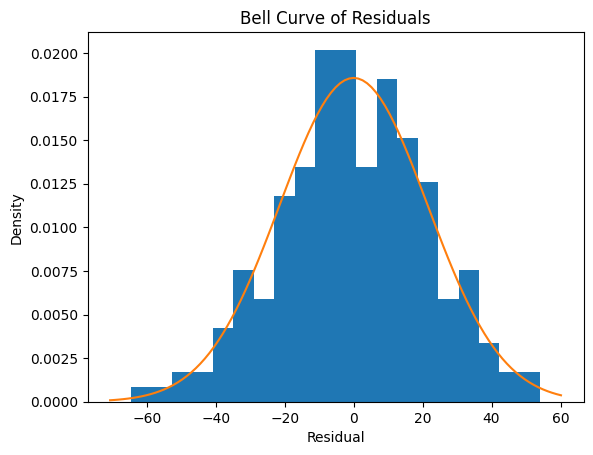

In [5]:
# Plot histogram of residuals
plt.hist(df["Residual"], bins=20, density=True)

# Add normal distribution curve
mu = df["Residual"].mean()
sigma = df["Residual"].std()

xmin, xmax = plt.xlim()
x = pd.Series(
    [xmin + (xmax - xmin) * i / 100 for i in range(101)]
)

normal_curve = (
    1 / (sigma * (2 * 3.14159) ** 0.5)
) * (
    2.71828 ** (-0.5 * ((x - mu) / sigma) ** 2)
)

plt.plot(x, normal_curve)

# Add labels and title
plt.xlabel("Residual")
plt.ylabel("Density")
plt.title("Bell Curve of Residuals")

# Display plot
plt.show()

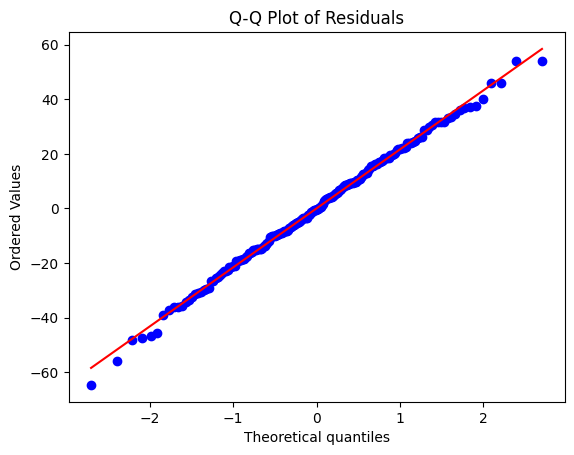

In [6]:
# Create Q-Q plot for residuals
stats.probplot(df["Residual"], dist="norm", plot=plt)

# Add title
plt.title("Q-Q Plot of Residuals")

# Display plot
plt.show()

In [13]:
# Calculate mean and standard deviation of residuals
mean_residual = df["Residual"].mean()
std_residual = df["Residual"].std()

# Calculate standardized residuals
df["Standardized_Residual"] = (
    (df["Residual"] - mean_residual) / std_residual
)

# Remove extreme residuals
df_clean = df[
    abs(df["Standardized_Residual"]) <= 2
].copy()

# Display number of rows
print("Original rows:", len(df))
print("Rows after removing outliers:", len(df_clean))

Original rows: 200
Rows after removing outliers: 190


In [14]:
# Select cleaned data
X_clean = df_clean[["Area_sqft"]]
y_clean = df_clean["Price_Lakhs"]

# Create new linear regression model
model_clean = LinearRegression()

# Train the model
model_clean.fit(X_clean, y_clean)

# Calculate new intercept and coefficient
b0_clean = model_clean.intercept_
b1_clean = model_clean.coef_[0]

# Predict values
y_pred_clean = model_clean.predict(X_clean)

# Calculate new residuals
df_clean["Predicted_Price"] = y_pred_clean
df_clean["Residual"] = (
    df_clean["Price_Lakhs"] -
    df_clean["Predicted_Price"]
)

# Calculate R²
r2_clean = r2_score(y_clean, y_pred_clean)

# Display results
print("New Intercept (b0):", b0_clean)
print("New Coefficient (b1):", b1_clean)
print("New R²:", r2_clean)

New Intercept (b0): 28.786777406926774
New Coefficient (b1): 0.08226610577630226
New R²: 0.9282839159201033


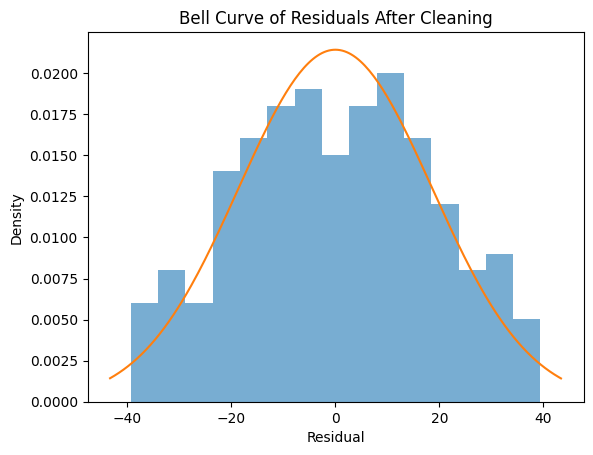

In [15]:
# Import normal distribution
from scipy.stats import norm

# Get residual values
residuals = df_clean["Residual"]

# Calculate mean and standard deviation
mu = residuals.mean()
sigma = residuals.std()

# Create histogram
plt.hist(
    residuals,
    bins=15,
    density=True,
    alpha=0.6
)

# Create x values for bell curve
xmin, xmax = plt.xlim()
x = pd.Series(
    [xmin + (xmax - xmin) * i / 200 for i in range(201)]
)

# Calculate normal distribution values
y = norm.pdf(x, mu, sigma)

# Plot bell curve
plt.plot(x, y)

# Add labels and title
plt.xlabel("Residual")
plt.ylabel("Density")
plt.title("Bell Curve of Residuals After Cleaning")

# Display plot
plt.show()

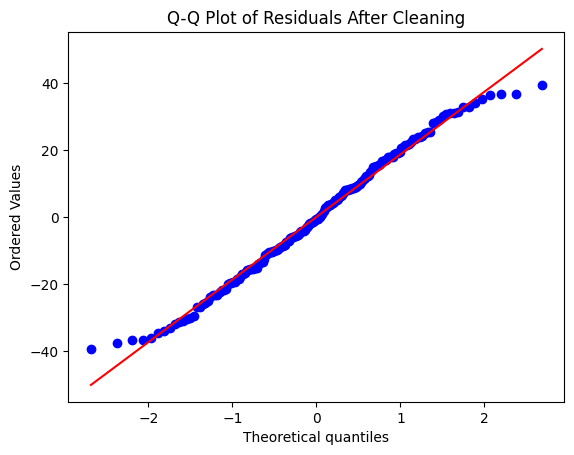

In [16]:
# Create Q-Q plot
stats.probplot(
    df_clean["Residual"],
    dist="norm",
    plot=plt
)

# Add title
plt.title("Q-Q Plot of Residuals After Cleaning")

# Display plot
plt.show()